In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import SVC, OneClassSVM
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
from sklearn.cluster import KMeans,DBSCAN
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
import pickle


In [2]:
import seaborn as sns

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import gc

In [4]:
data = pd.read_csv("/content/drive/MyDrive/data/card_transdata.csv")
data.head()



,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


In [5]:
# Display the first few rows with fraud = 1
fraud_head_count = data[data['fraud'] == 1].head()
fraud_head_count


,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
13,2.131956,56.372401,6.358667,1.0,0.0,0.0,1.0,1.0
24,3.803057,67.241081,1.872950,1.0,0.0,0.0,1.0,1.0
29,15.694986,175.989182,0.855623,1.0,0.0,0.0,1.0,1.0
35,26.711462,1.552008,4.603601,1.0,1.0,0.0,1.0,1.0
36,10.664474,1.565769,4.886521,1.0,0.0,0.0,1.0,1.0


In [6]:
data["fraud"].value_counts()

,count
fraud,
0.0,912597
1.0,87403


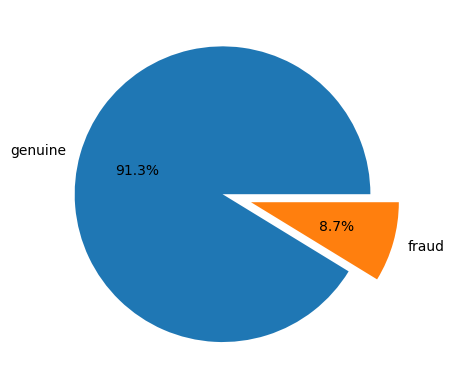

In [7]:
vc = data["fraud"].value_counts()

plt.pie(x=vc.values, labels=['genuine','fraud'], explode=[0.0, 0.2], autopct='%1.1f%%')
plt.show()

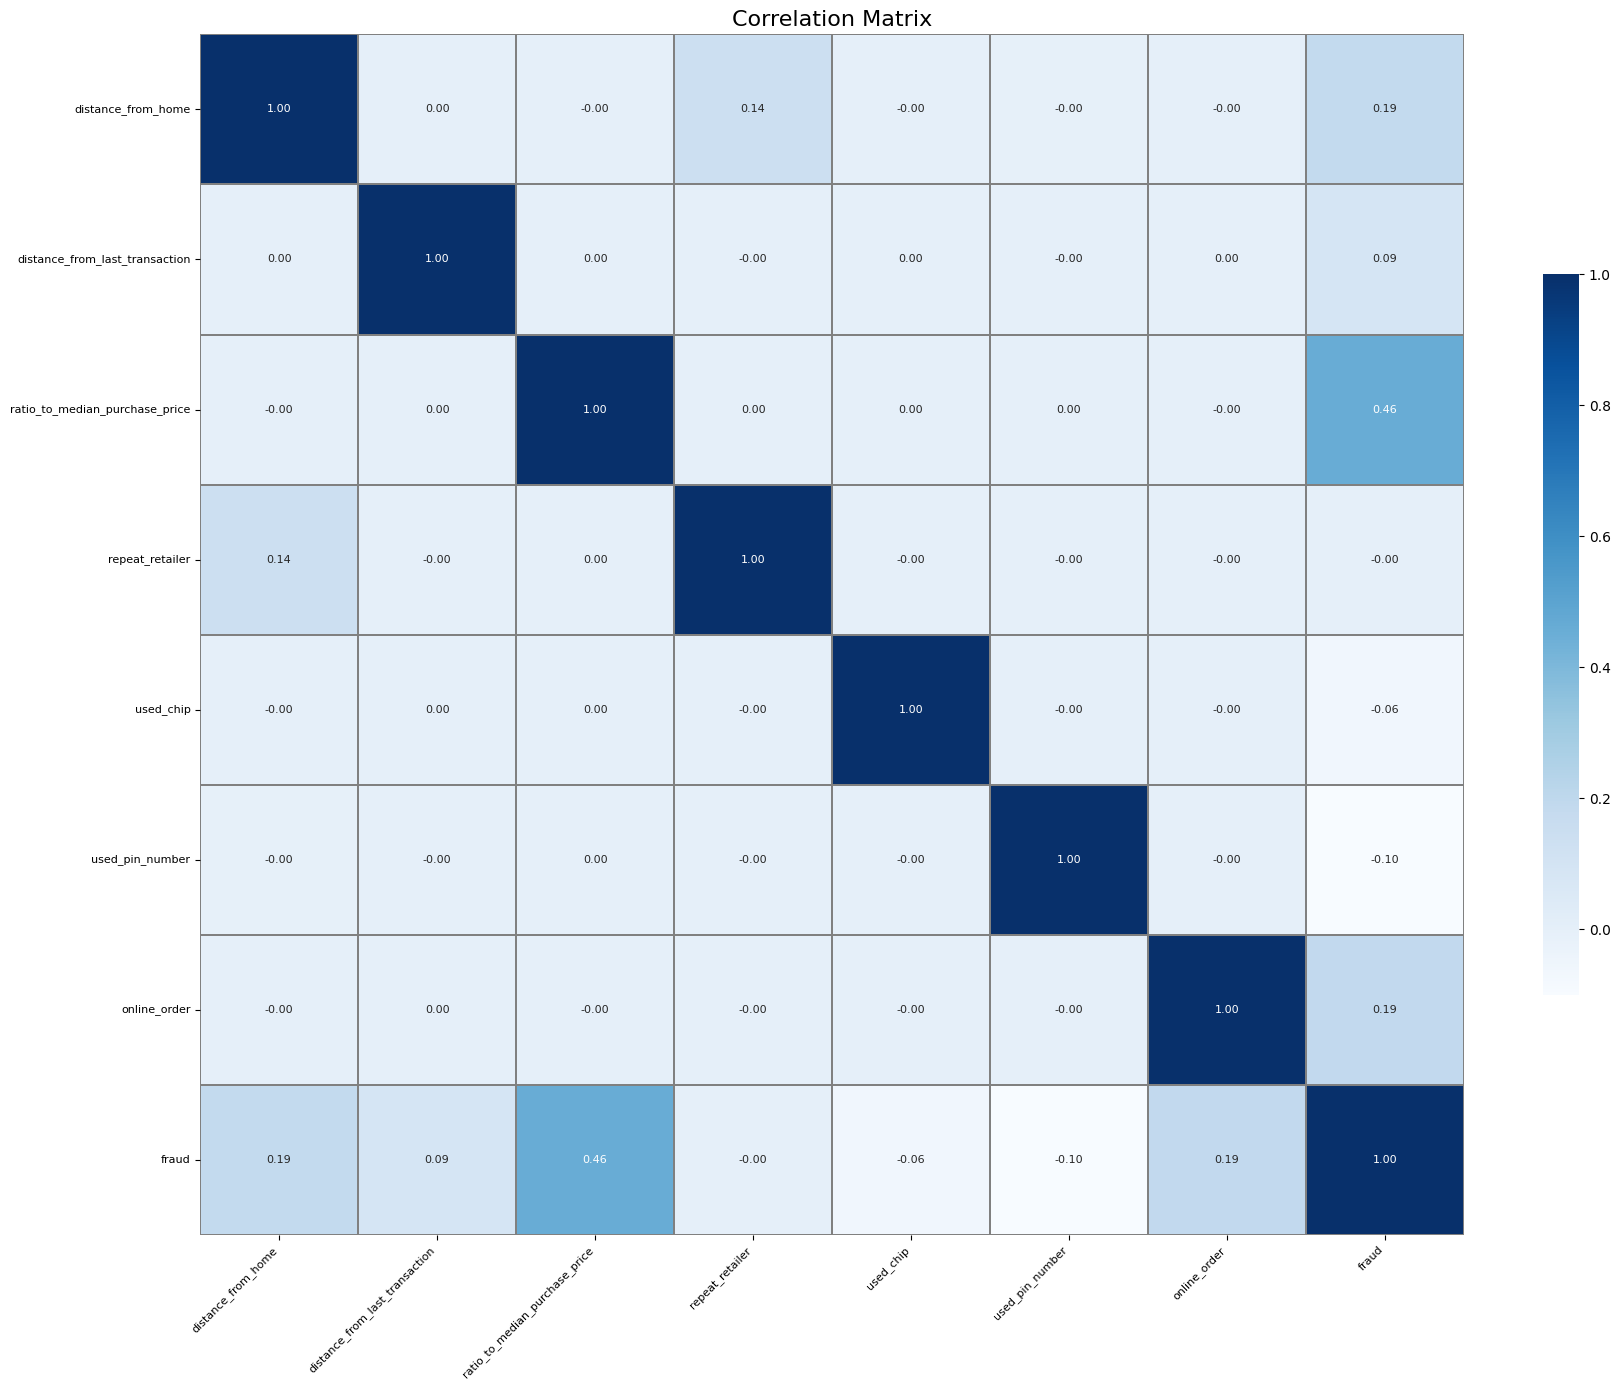

In [8]:
plt.figure(figsize=(18, 14))
sns.heatmap(
    data.corr(),
    annot=True,
    fmt='.2f',
    cmap='Blues',
    annot_kws={"size": 8},
    linewidths=0.1,
    linecolor='gray',
    cbar_kws={"shrink": 0.6}
)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.title('Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()


In [9]:
from re import A
supervised_models = {
    "log_reg": LogisticRegression(max_iter=1000),
    "random_forest": RandomForestClassifier(),
    "xgboost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
}

In [10]:
X=data.drop(["fraud"],axis=1)
y=data["fraud"]

In [11]:
results = {}

In [12]:
def plot_metrics(y_test, y_pred, y_score, title):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {title}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print(f"Classification Report - {title}:")
    print(classification_report(y_test, y_pred))

    fpr, tpr, _ = roc_curve(y_test, y_score)
    plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_score(y_test, y_score):.2f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(f"ROC Curve - {title}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid()
    plt.show()

In [13]:
from sklearn.utils import resample
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE, ADASYN
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

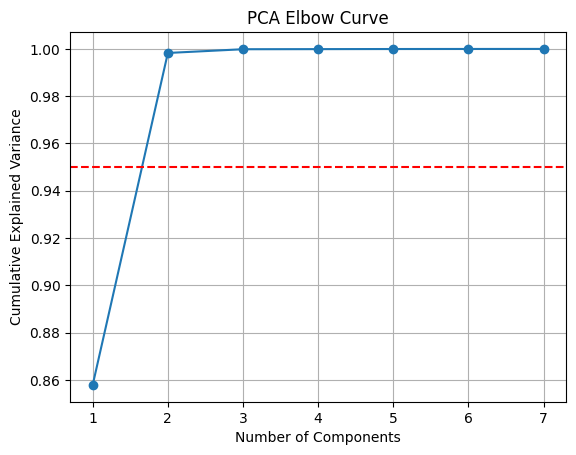

In [15]:
import matplotlib.pyplot as plt
import numpy as np

pca = PCA().fit(X_train)
explained_variance = np.cumsum(pca.explained_variance_ratio_)

plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Elbow Curve')
plt.grid()
plt.show()

In [16]:
# 1. ORIGINAL DATA
X_original = X_train.copy()
y_original = y_train.copy()

# 2. RANDOM SAMPLING (50%)
X_rand, y_rand = resample(X, y,
                          replace=False,
                          n_samples=int(0.5 * len(X_train)),
                          random_state=42)

# 3. SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

# 4. ADASYN
adasyn = ADASYN(random_state=42)
X_adasyn, y_adasyn = adasyn.fit_resample(X, y)




=== Dataset: ORIGINAL ===
Training Supervised: log_reg


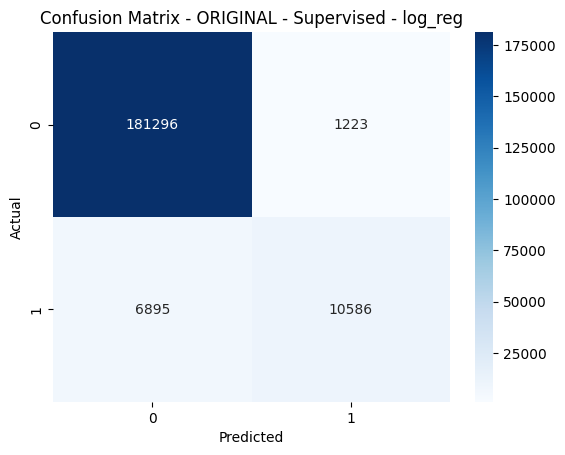

Classification Report - ORIGINAL - Supervised - log_reg:
              precision    recall  f1-score   support

         0.0       0.96      0.99      0.98    182519
         1.0       0.90      0.61      0.72     17481

    accuracy                           0.96    200000
   macro avg       0.93      0.80      0.85    200000
weighted avg       0.96      0.96      0.96    200000



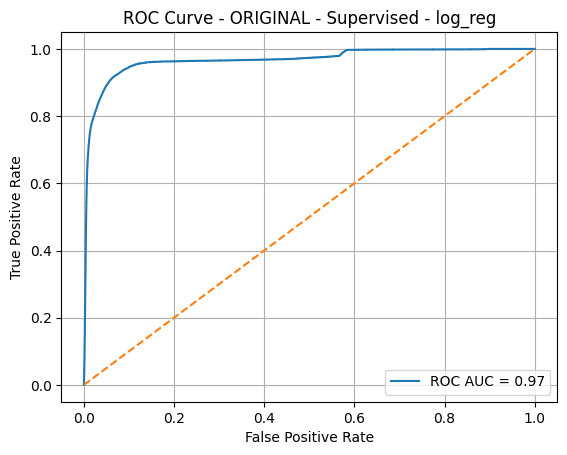

Training Supervised: random_forest


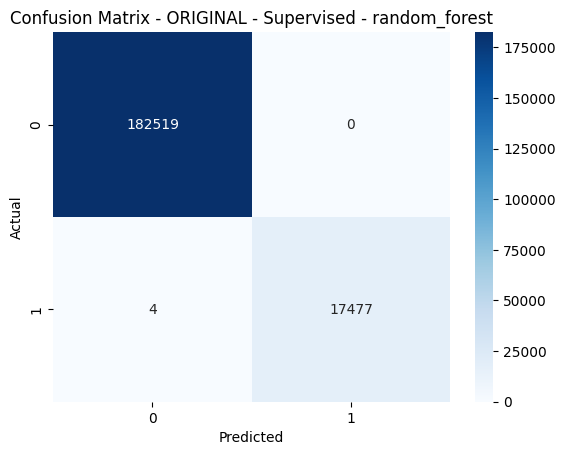

Classification Report - ORIGINAL - Supervised - random_forest:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    182519
         1.0       1.00      1.00      1.00     17481

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000



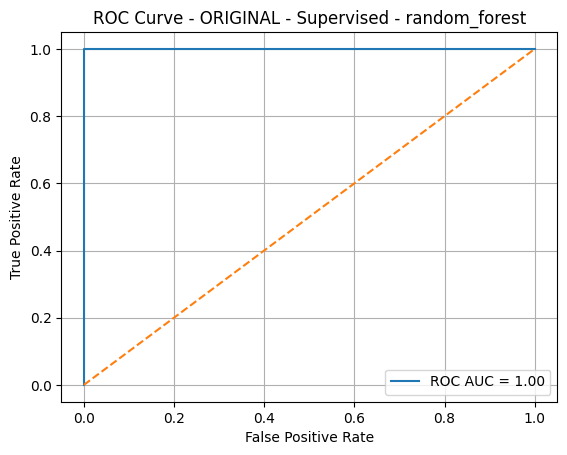

Training Supervised: xgboost


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:30:24] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


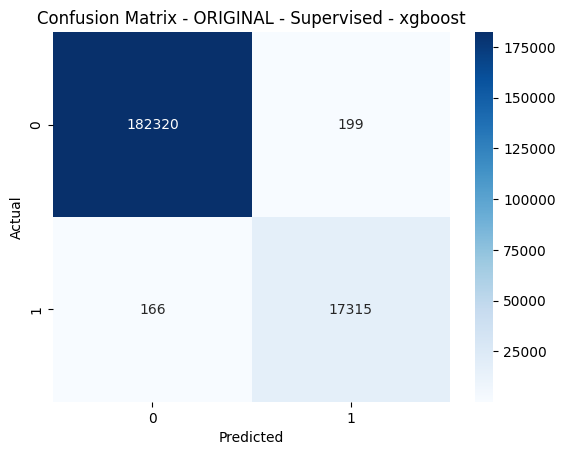

Classification Report - ORIGINAL - Supervised - xgboost:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    182519
         1.0       0.99      0.99      0.99     17481

    accuracy                           1.00    200000
   macro avg       0.99      0.99      0.99    200000
weighted avg       1.00      1.00      1.00    200000



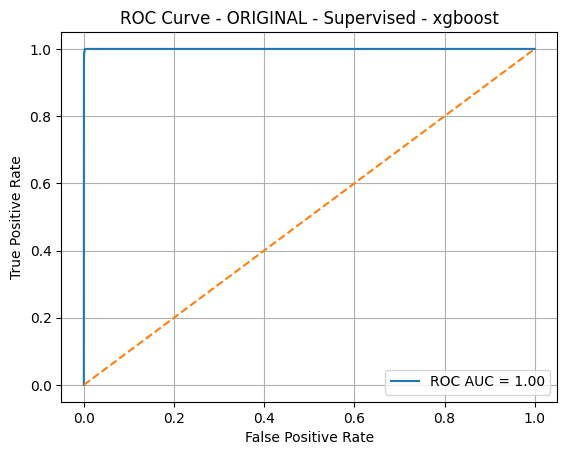


=== Dataset: RANDOM ===
Training Supervised: log_reg


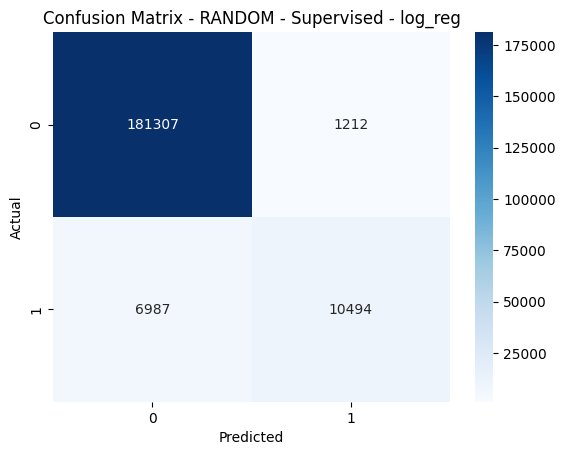

Classification Report - RANDOM - Supervised - log_reg:
              precision    recall  f1-score   support

         0.0       0.96      0.99      0.98    182519
         1.0       0.90      0.60      0.72     17481

    accuracy                           0.96    200000
   macro avg       0.93      0.80      0.85    200000
weighted avg       0.96      0.96      0.96    200000



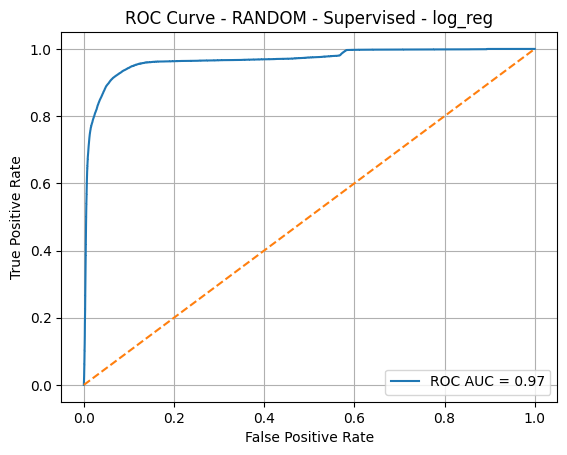

Training Supervised: random_forest


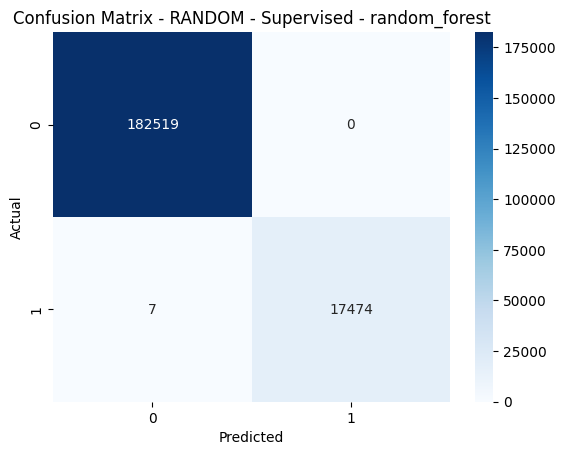

Classification Report - RANDOM - Supervised - random_forest:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    182519
         1.0       1.00      1.00      1.00     17481

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000



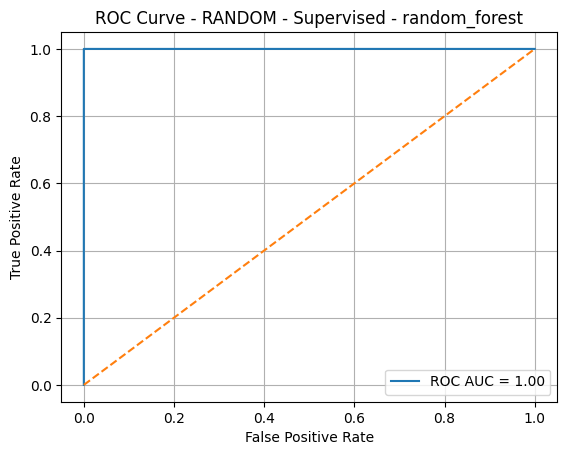

Training Supervised: xgboost


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:31:30] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


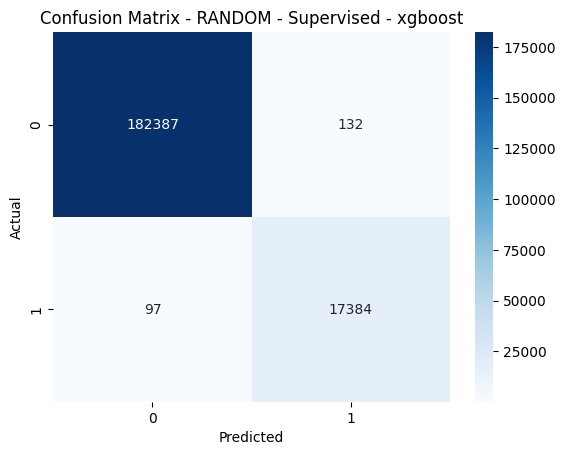

Classification Report - RANDOM - Supervised - xgboost:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    182519
         1.0       0.99      0.99      0.99     17481

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000



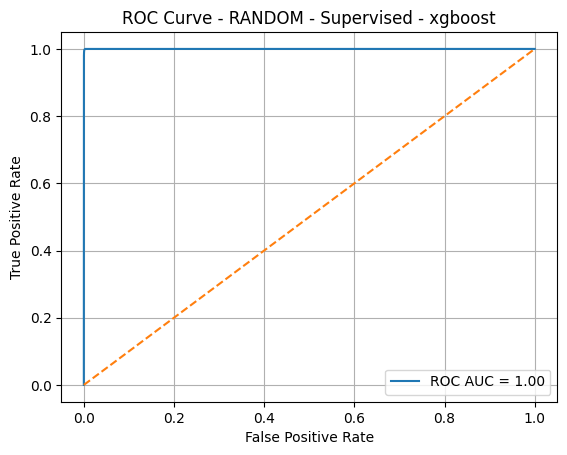


=== Dataset: SMOTE ===
Training Supervised: log_reg


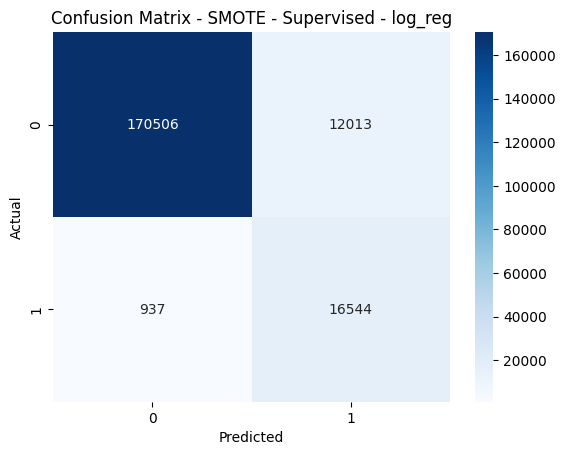

Classification Report - SMOTE - Supervised - log_reg:
              precision    recall  f1-score   support

         0.0       0.99      0.93      0.96    182519
         1.0       0.58      0.95      0.72     17481

    accuracy                           0.94    200000
   macro avg       0.79      0.94      0.84    200000
weighted avg       0.96      0.94      0.94    200000



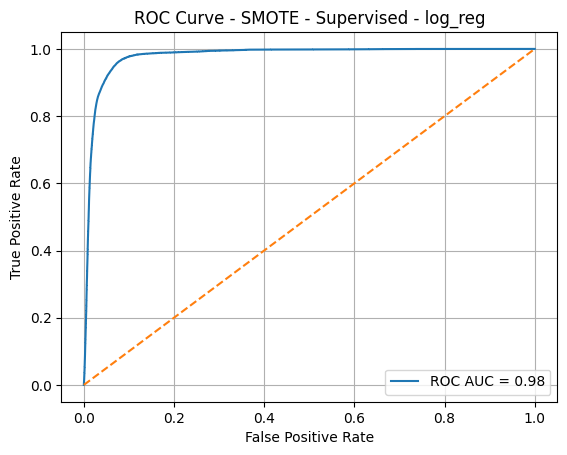

Training Supervised: random_forest


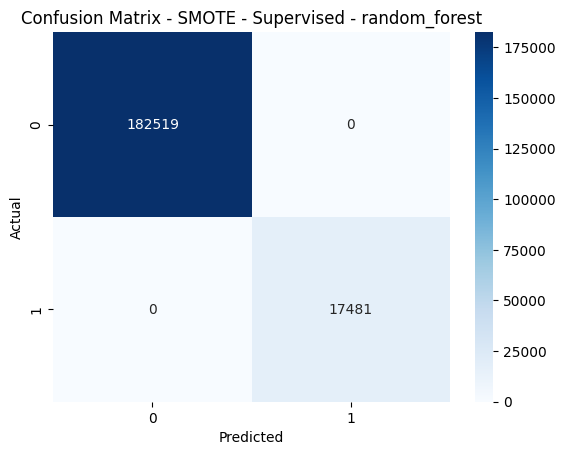

Classification Report - SMOTE - Supervised - random_forest:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    182519
         1.0       1.00      1.00      1.00     17481

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000



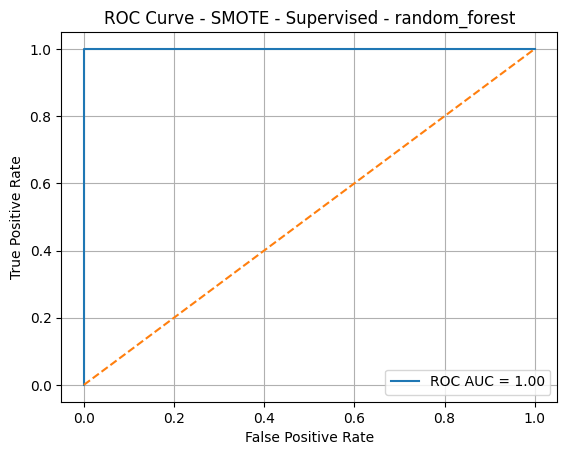

Training Supervised: xgboost


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:38:17] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


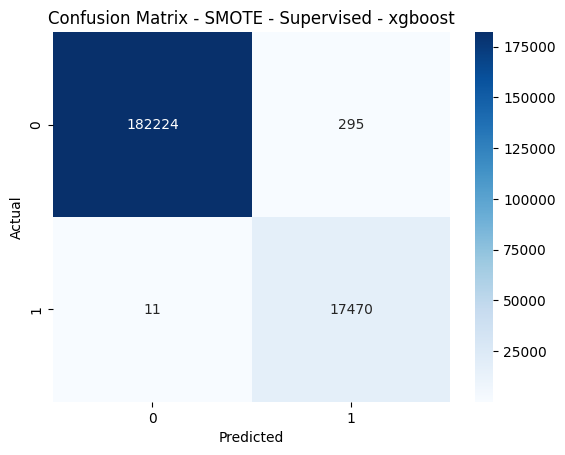

Classification Report - SMOTE - Supervised - xgboost:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    182519
         1.0       0.98      1.00      0.99     17481

    accuracy                           1.00    200000
   macro avg       0.99      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000



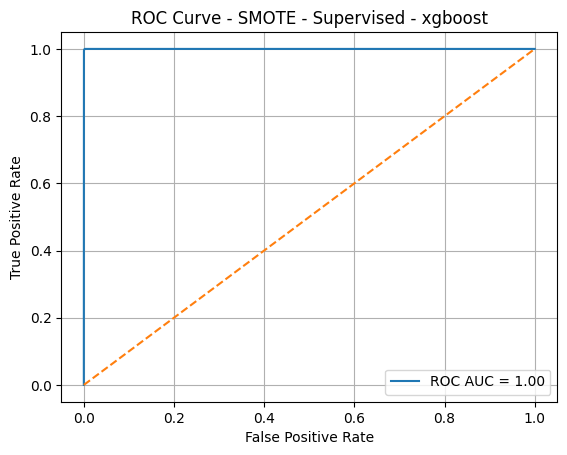


=== Dataset: ADASYN ===
Training Supervised: log_reg


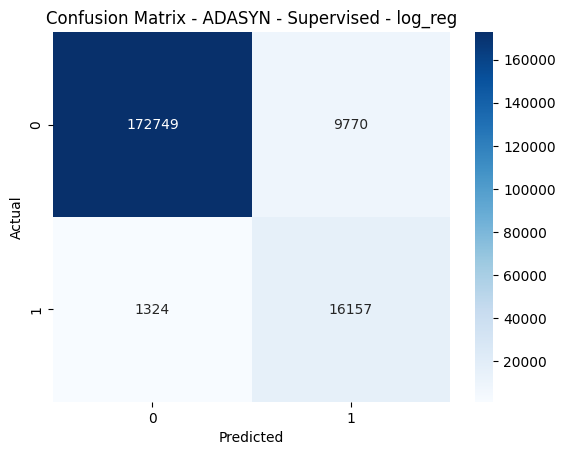

Classification Report - ADASYN - Supervised - log_reg:
              precision    recall  f1-score   support

         0.0       0.99      0.95      0.97    182519
         1.0       0.62      0.92      0.74     17481

    accuracy                           0.94    200000
   macro avg       0.81      0.94      0.86    200000
weighted avg       0.96      0.94      0.95    200000



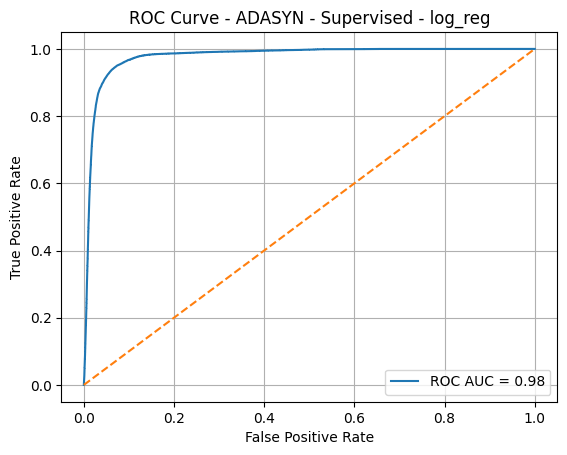

Training Supervised: random_forest


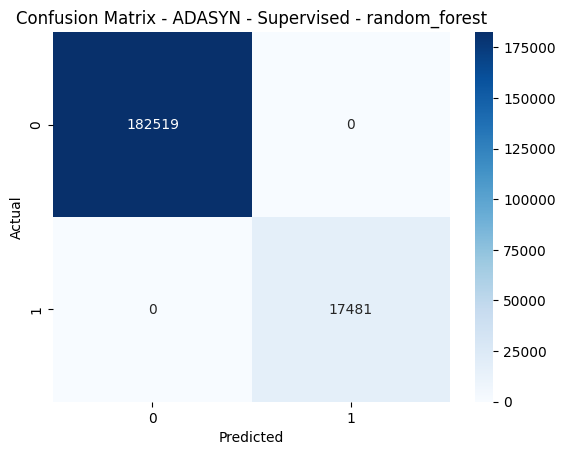

Classification Report - ADASYN - Supervised - random_forest:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    182519
         1.0       1.00      1.00      1.00     17481

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000



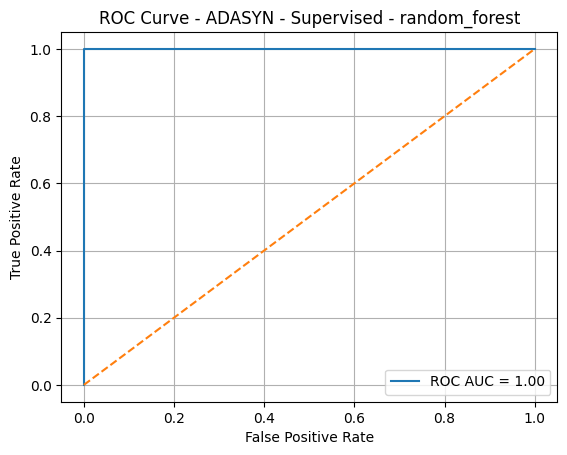

Training Supervised: xgboost


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:44:02] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


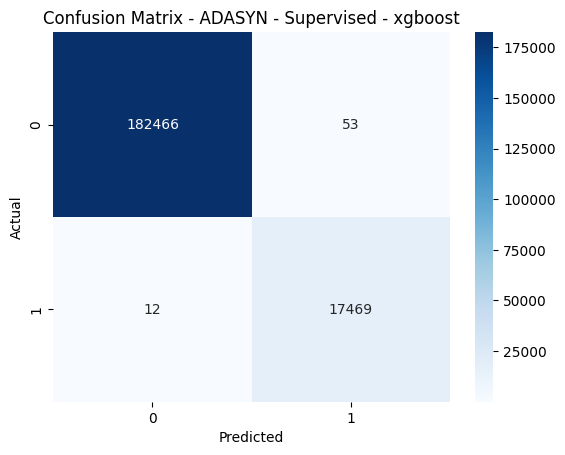

Classification Report - ADASYN - Supervised - xgboost:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    182519
         1.0       1.00      1.00      1.00     17481

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000



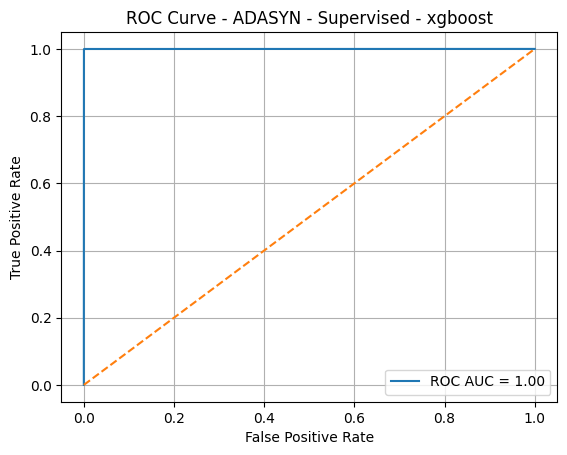

In [18]:
import gc
import pickle
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import mode

results = {}

# Define datasets
datasets = {
    "original": (X_original, y_original),
    "random": (X_rand, y_rand),
    "smote": (X_smote, y_smote),
    "adasyn": (X_adasyn, y_adasyn),
    # "pca": (X_pca, y_pca),
}

for data_name, (X_train_var, y_train_var) in datasets.items():
    print(f"\n=== Dataset: {data_name.upper()} ===")

    # Preprocess
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_var)
    X_test_scaled = scaler.transform(X_test)
    y_train_scaled = y_train_var

    # Save scaler for ANN use later if needed
    if data_name == "original":
        with open("scaler.pkl", "wb") as f:
            pickle.dump(scaler, f)

    # --- SUPERVISED MODELS ---
    for name, base_model in supervised_models.items():
        print(f"Training Supervised: {name}")
        model = base_model.__class__(**base_model.get_params())
        model.fit(X_train_scaled, y_train_scaled)


        y_pred = model.predict(X_test_scaled)
        y_score = (model.predict_proba(X_test_scaled)[:, 1]
                    if hasattr(model, "predict_proba")
                    else model.decision_function(X_test_scaled))
        with open(f"/content/drive/MyDrive/data/{data_name}_{name}_model.pkl", "wb") as f:
                pickle.dump(model, f)

        score = roc_auc_score(y_test, y_score)
        results[f"{data_name}_sup_{name}"] = score

        plot_metrics(y_test, y_pred, y_score, f"{data_name.upper()} - Supervised - {name}")

    gc.collect()
